In [20]:
# Core libs
import os
import pickle
import random
import re
import time
from collections import Counter
from pathlib import Path

# Data + modeling libs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import redivis
import tensorflow as tf
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# Reproducibility
SEED = 12345
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

> **Note:** This setup script only needs to be **run once**. It loads and downloads all the data into your local folder, which takes approximately **45 minutes** to complete.

```python
from pathlib import Path
import re
import pandas as pd
import redivis

# NOTE: This script loads all the dataset files and only needs to be run once.
# Expect the download process to take around 45 minutes to complete.

labels_dir = Path(".")
out_dir = Path("./StanfordMRNet")

dataset = redivis.organization("AIMI").dataset("mrnet_knee_mri_s:4a2c")

for split in ["train", "valid"]:
    labels_path = labels_dir / f"{split}_acl_labels.csv"
    if not labels_path.exists():
        raise FileNotFoundError(f"Missing {labels_path}")

    labels = pd.read_csv(labels_path)
    id_col = "volumeFilename" if "volumeFilename" in labels.columns else labels.columns[0]

    keep_ids = {
        int(match.group())
        for value in labels[id_col].dropna()
        if (match := re.search(r"\d+", str(value)))
    }

    split_dir = out_dir / split
    split_dir.mkdir(parents=True, exist_ok=True)

    table = dataset.table(split)
    df = table.to_pandas_dataframe()

    for _, row in df.iterrows():
        file_name = str(row["file_name"])
        match = re.search(r"\d+", Path(file_name).stem)

        if not match or int(match.group()) not in keep_ids:
            continue

        file_path = split_dir / file_name
        if not file_path.exists():
            file_path.parent.mkdir(parents=True, exist_ok=True)
            table.file(row["file_id"]).download(str(file_path))

In [21]:
# Map raw ACL labels to binary labels: 0=normal, 1=torn
def to_binary_label(raw_label):
    if pd.isna(raw_label):
        return None
    v = int(raw_label)
    return 1 if v == 2 else v

# Extract numeric case id from strings like filenames
def extract_case_id(value):
    m = re.search(r"\d+", str(value))
    return int(m.group()) if m else None

# Pick likely id/label columns if schema varies
def infer_columns(df):
    cols = list(df.columns)
    id_candidates = ["volumeFilename", "file_name", "filename", "case", "case_id", "id"]
    lbl_candidates = ["aclDiagnosis", "acl_label", "label", "acl"]

    id_col = next((c for c in id_candidates if c in cols), cols[0])
    label_col = next((c for c in lbl_candidates if c in cols), cols[-1])
    return id_col, label_col

# Build case_id -> label map from csv
def load_split_label_map(csv_path):
    df = pd.read_csv(csv_path)
    id_col, label_col = infer_columns(df)

    return {
        cid: lbl
        for _, row in df.iterrows()
        if (cid := extract_case_id(row[id_col])) is not None
        if (lbl := to_binary_label(row[label_col])) is not None
    }

# Keep only files that have labels
def map_paths_to_labels(paths, label_map):
    return [
        (p, label_map[cid])
        for p in paths
        if (cid := extract_case_id(p.stem)) in label_map
    ]

# Sagittal split paths
train_sag_dir = Path("StanfordMRNet/train/sagittal")
valid_sag_dir = Path("StanfordMRNet/valid/sagittal")

train_paths = sorted(train_sag_dir.glob("*.npy"))
valid_paths = sorted(valid_sag_dir.glob("*.npy"))

# Load train/valid labels
train_label_map = load_split_label_map("train_acl_labels.csv")
valid_label_map = load_split_label_map("valid_acl_labels.csv")

train_mapped = map_paths_to_labels(train_paths, train_label_map)
valid_mapped = map_paths_to_labels(valid_paths, valid_label_map)

label_names = {0: "Normal", 1: "Torn"}

print(f"Train sagittal files: {len(train_paths)}, labeled: {len(train_mapped)}")
print(f"Valid sagittal files: {len(valid_paths)}, labeled: {len(valid_mapped)}")
print("Train class counts:", dict(Counter(y for _, y in train_mapped)))
print("Valid class counts:", dict(Counter(y for _, y in valid_mapped)))

Train sagittal files: 1129, labeled: 1129
Valid sagittal files: 119, labeled: 119
Train class counts: {1: 208, 0: 921}
Valid class counts: {0: 65, 1: 54}


In [22]:
# Sampling + feature params
MAX_SAMPLES = 400
IMG_SIZE = (64, 64)
hog_params = {"orientations": 9, "pixels_per_cell": (8, 8), "cells_per_block": (2, 2)}

def load_volume(path):
    return np.load(path, allow_pickle=True)

# Build one grayscale slice for HOG and 3-channel image for CNN
def prepare_volume_inputs(volume, image_size):
    volume_arr = np.asarray(volume)

    if volume_arr.ndim == 3 and volume_arr.shape[0] >= 3:
        center_idx = volume_arr.shape[0] // 2
        slice_indices = [max(0, center_idx - 1), center_idx, min(volume_arr.shape[0] - 1, center_idx + 1)]
        channels = []
        for slice_index in slice_indices:
            slice_image = volume_arr[slice_index]
            if slice_image.ndim == 3:
                slice_image = rgb2gray(slice_image)
            slice_resized = resize(slice_image, image_size, anti_aliasing=True)
            channels.append(slice_resized.astype(np.float32))
        return channels[1], np.stack(channels, axis=-1)

    center_slice = volume_arr[volume_arr.shape[0] // 2] if volume_arr.ndim == 3 else volume_arr
    if center_slice.ndim == 3:
        center_slice = rgb2gray(center_slice)
    center_slice = resize(center_slice, image_size, anti_aliasing=True)
    return center_slice, np.stack([center_slice.astype(np.float32)] * 3, axis=-1)

# Convert mapped file list into model-ready arrays
def build_split_arrays(mapped_split, cache_path=None, max_samples=None):
    if cache_path and Path(cache_path).exists():
        d = np.load(cache_path, allow_pickle=True)
        return d["X_hog"], d["X_images"], d["y_labels"]

    rng = random.Random(SEED)
    by_label = {}
    for p, y in mapped_split:
        by_label.setdefault(y, []).append(p)

    # Optional per-class sampling for faster training
    selected = []
    if max_samples is None:
        for y in sorted(by_label):
            selected.extend([(p, y) for p in by_label[y]])
    else:
        n_classes = max(1, len(by_label))
        per_class = max(1, max_samples // n_classes)
        for y in sorted(by_label):
            picks = by_label[y]
            take = min(len(picks), per_class)
            chosen = rng.sample(picks, take) if len(picks) > take else picks
            selected.extend([(p, y) for p in chosen])

    hog_features_list, image_tensors_list, labels_list = [], [], []
    t0 = time.time()
    for p, y in selected:
        vol = load_volume(p)
        slice_resized, cnn_img = prepare_volume_inputs(vol, IMG_SIZE)

        hog_descriptor = hog(
            (slice_resized * 255).astype(np.uint8),
            orientations=hog_params["orientations"],
            pixels_per_cell=hog_params["pixels_per_cell"],
            cells_per_block=hog_params["cells_per_block"],
            visualize=False,
            feature_vector=True,
        )
        hog_features_list.append(hog_descriptor)
        image_tensors_list.append(cnn_img)
        labels_list.append(y)

    X_hog = np.vstack(hog_features_list)
    X_images = np.stack(image_tensors_list)
    y_labels = np.array(labels_list)

    if cache_path:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_path, X_hog=X_hog, X_images=X_images, y_labels=y_labels)

    print(f"Built {len(y_labels)} samples in {time.time()-t0:.1f}s from {cache_path}")
    return X_hog, X_images, y_labels

X_hog_train, X_images_train, y_images_train = build_split_arrays(
    train_mapped, cache_path="cache/preprocessed_train_sagittal.npz", max_samples=MAX_SAMPLES
)
X_hog_test, X_images_val, y_images_val = build_split_arrays(
    valid_mapped, cache_path="cache/preprocessed_valid_sagittal.npz", max_samples=None
)

print("Train labels:", dict(Counter(y_images_train.tolist())))
print("Valid labels:", dict(Counter(y_images_val.tolist())))

# Inverse-frequency class weights for imbalance
class_counts = Counter(y_images_train.tolist())
classes = np.array(sorted(class_counts.keys()))
total = sum(class_counts.values())
class_weight_dict = {
    int(c): total / (len(classes) * class_counts[int(c)])
    for c in classes
}
sample_weight_train = np.array([class_weight_dict[int(y)] for y in y_images_train], dtype=np.float32)
print("Class weights:", class_weight_dict)

epochs = 50
sgd_svm = SGDClassifier(loss="hinge", random_state=SEED)
for _ in range(epochs):
    sgd_svm.partial_fit(
        X_hog_train,
        y_images_train,
        classes=np.array([0, 1]),
        sample_weight=sample_weight_train,
    )

sgd_logr = SGDClassifier(loss="log_loss", random_state=SEED)
for _ in range(epochs):
    sgd_logr.partial_fit(
        X_hog_train,
        y_images_train,
        classes=np.array([0, 1]),
        sample_weight=sample_weight_train,
    )

y_hog_test = y_images_val
print("SGD-SVM acc:", accuracy_score(y_hog_test, sgd_svm.predict(X_hog_test)))
print("SGD-LogReg acc:", accuracy_score(y_hog_test, sgd_logr.predict(X_hog_test)))

labels_sorted = sorted(np.unique(y_hog_test))
label_names_for_report = [label_names.get(int(i), str(int(i))) for i in labels_sorted]
print("\nSGD-SVM classification report:\n")
print(classification_report(y_hog_test, sgd_svm.predict(X_hog_test), labels=labels_sorted, target_names=label_names_for_report))
print("\nSGD-LogReg classification report:\n")
print(classification_report(y_hog_test, sgd_logr.predict(X_hog_test), labels=labels_sorted, target_names=label_names_for_report))

Train labels: {0: 200, 1: 200}
Valid labels: {0: 65, 1: 54}
Class weights: {0: 1.0, 1: 1.0}
SGD-SVM acc: 0.6218487394957983
SGD-LogReg acc: 0.6050420168067226

SGD-SVM classification report:

              precision    recall  f1-score   support

      Normal       0.65      0.68      0.66        65
        Torn       0.59      0.56      0.57        54

    accuracy                           0.62       119
   macro avg       0.62      0.62      0.62       119
weighted avg       0.62      0.62      0.62       119


SGD-LogReg classification report:

              precision    recall  f1-score   support

      Normal       0.66      0.57      0.61        65
        Torn       0.56      0.65      0.60        54

    accuracy                           0.61       119
   macro avg       0.61      0.61      0.60       119
weighted avg       0.61      0.61      0.61       119



In [23]:
# CNN training + evaluation
X_images_train = np.clip(X_images_train, 0.0, 1.0)
X_images_val = np.clip(X_images_val, 0.0, 1.0)

# Show class balance
unique, counts = np.unique(y_images_train, return_counts=True)
print("Image-train class counts:", dict(zip(unique.astype(int).tolist(), counts.tolist())))

# Inverse-frequency class weights
total = int(np.sum(counts))
class_weight_dict = {
    int(c): total / (len(unique) * int(n))
    for c, n in zip(unique, counts)
}
print("CNN class weights:", class_weight_dict)

# Simpler binary CNN
model = models.Sequential([
    layers.Input(shape=X_images_train.shape[1:]),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

opt = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])

print("\nTraining CNN...")
history = model.fit(
    X_images_train,
    y_images_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_images_val, y_images_val),
    verbose=2,
    class_weight=class_weight_dict,
)

loss, acc = model.evaluate(X_images_val, y_images_val, verbose=0)
print("\nCNN validation acc:", acc)

# Validation predictions + report
y_prob_cnn = model.predict(X_images_val).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
labels_sorted_img = sorted(np.unique(y_images_val))
label_names_for_report_img = [label_names.get(int(i), str(int(i))) for i in labels_sorted_img]
print("\nCNN classification report:\n")
print(classification_report(y_images_val, y_pred_cnn, labels=labels_sorted_img, target_names=label_names_for_report_img))

# Confusion matrix
cm = confusion_matrix(y_images_val, y_pred_cnn, labels=labels_sorted_img)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

Image-train class counts: {0: 200, 1: 200}
CNN class weights: {0: 1.0, 1: 1.0}

Training CNN...
Epoch 1/50
25/25 - 1s - 29ms/step - accuracy: 0.4875 - loss: 0.6947 - val_accuracy: 0.5462 - val_loss: 0.6921
Epoch 2/50
25/25 - 0s - 10ms/step - accuracy: 0.4675 - loss: 0.6950 - val_accuracy: 0.5462 - val_loss: 0.6921
Epoch 3/50
25/25 - 0s - 10ms/step - accuracy: 0.5050 - loss: 0.6933 - val_accuracy: 0.5462 - val_loss: 0.6924
Epoch 4/50
25/25 - 0s - 12ms/step - accuracy: 0.4875 - loss: 0.6937 - val_accuracy: 0.5462 - val_loss: 0.6921
Epoch 5/50
25/25 - 0s - 10ms/step - accuracy: 0.5100 - loss: 0.6917 - val_accuracy: 0.5462 - val_loss: 0.6919
Epoch 6/50
25/25 - 0s - 11ms/step - accuracy: 0.5175 - loss: 0.6927 - val_accuracy: 0.5462 - val_loss: 0.6914
Epoch 7/50
25/25 - 0s - 10ms/step - accuracy: 0.5350 - loss: 0.6917 - val_accuracy: 0.5462 - val_loss: 0.6919
Epoch 8/50
25/25 - 0s - 11ms/step - accuracy: 0.5475 - loss: 0.6918 - val_accuracy: 0.5462 - val_loss: 0.6922
Epoch 9/50
25/25 - 0s - 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Model comparison:
     model  accuracy  precision   recall  f1_score
   SGD-SVM  0.621849   0.588235 0.555556  0.571429
SGD-LogReg  0.605042   0.555556 0.648148  0.598291
       CNN  0.714286   0.651515 0.796296  0.716667


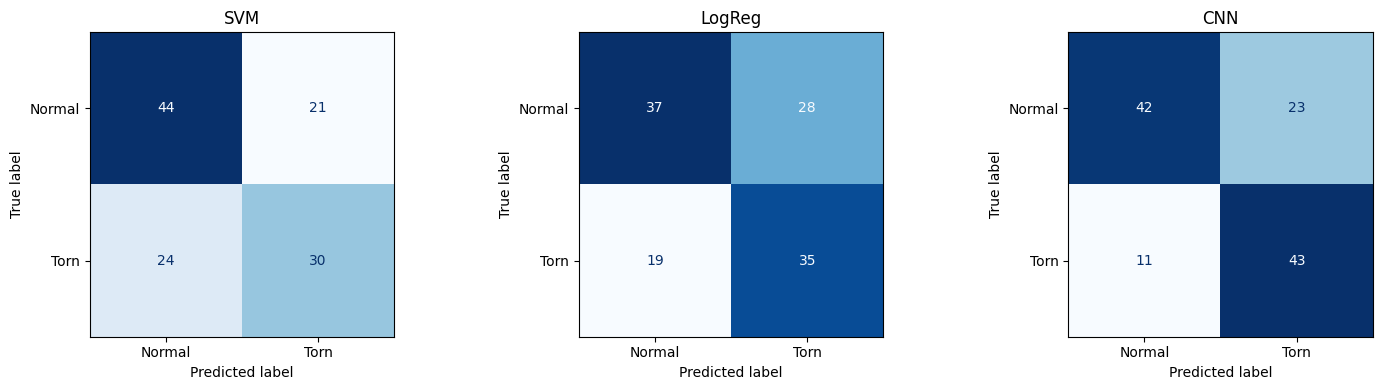

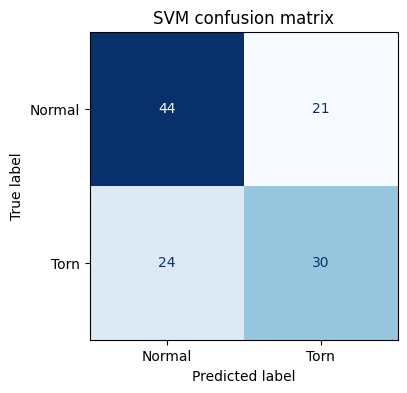

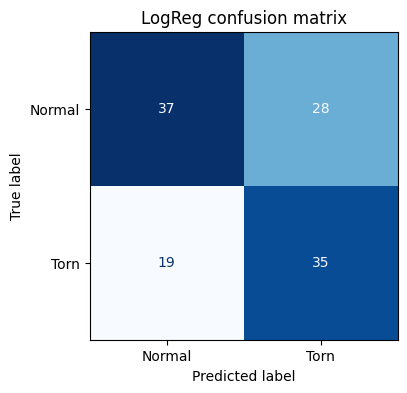

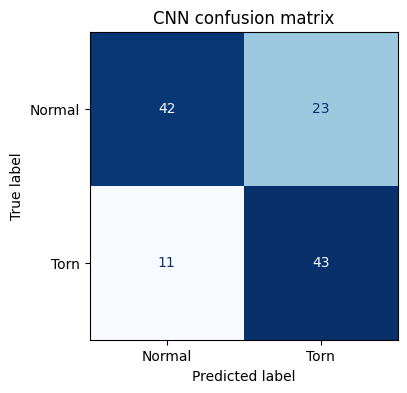

In [24]:
# Unified model comparison
# Collect predictions from all models
y_pred_svm = sgd_svm.predict(X_hog_test)
y_pred_logr = sgd_logr.predict(X_hog_test)
y_prob_cnn = model.predict(X_images_val).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)


def _metrics(y_true, y_pred):
    """Return accuracy, precision, recall, and F1 for binary labels."""
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return acc, prec, rec, f1


acc_svm, prec_svm, rec_svm, f1_svm = _metrics(y_hog_test, y_pred_svm)
acc_logr, prec_logr, rec_logr, f1_logr = _metrics(y_hog_test, y_pred_logr)
acc_cnn, prec_cnn, rec_cnn, f1_cnn = _metrics(y_images_val, y_pred_cnn)

# Compact metric table
results_df = pd.DataFrame({
    "model": ["SGD-SVM", "SGD-LogReg", "CNN"],
    "accuracy": [acc_svm, acc_logr, acc_cnn],
    "precision": [prec_svm, prec_logr, prec_cnn],
    "recall": [rec_svm, rec_logr, rec_cnn],
    "f1_score": [f1_svm, f1_logr, f1_cnn],
})
print("\nModel comparison:")
print(results_df.to_string(index=False))

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    ("SVM", y_hog_test, y_pred_svm),
    ("LogReg", y_hog_test, y_pred_logr),
    ("CNN", y_images_val, y_pred_cnn),
]
for ax, (name, y_true, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[0], label_names[1]])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()

# Individual confusion matrices
models_info_for_plot = [
    ("SVM", y_hog_test, y_pred_svm),
    ("LogReg", y_hog_test, y_pred_logr),
    ("CNN", y_images_val, y_pred_cnn),
]
for name, y_true, y_pred in models_info_for_plot:
    cm_single = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig_single, ax_single = plt.subplots(figsize=(4, 4))
    disp_single = ConfusionMatrixDisplay(confusion_matrix=cm_single, display_labels=[label_names[0], label_names[1]])
    disp_single.plot(ax=ax_single, cmap="Blues", colorbar=False)
    ax_single.set_title(f"{name} confusion matrix")
    plt.show()